<a href="https://colab.research.google.com/github/NitiSivakumarAnavai/NitiSivakumarAnavai/blob/main/int510_cancer_detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


In [2]:
# IMPORTANT: Adjust this path based on where 'archive(6)' is located in YOUR Google Drive.
# This assumes 'archive(6)' is directly in 'My Drive/'.
# If it's inside another folder (e.g., 'My Drive/Colab Notebooks/archive(6)'), adjust accordingly.
data_dir = '/content/drive/My Drive/archive (6)/'

print(f"Data directory set to: {data_dir}")

# Let's verify the contents to be sure
print("\nContents of the specified data directory:")
!ls -F "{data_dir}"
!ls -F "{data_dir}data/" # Check inside the 'data' folder

Data directory set to: /content/drive/My Drive/archive (6)/

Contents of the specified data directory:
annotations.csv  Data/
ls: cannot access '/content/drive/My Drive/archive (6)/data/': No such file or directory


In [3]:
import os

data_dir = '/content/drive/My Drive/archive (6)/'

print(f"Listing contents of: {data_dir}")
!ls -F "{data_dir}"

print(f"\nListing contents of: {os.path.join(data_dir, 'Data')}")
!ls -F "{os.path.join(data_dir, 'Data')}"

Listing contents of: /content/drive/My Drive/archive (6)/
annotations.csv  Data/

Listing contents of: /content/drive/My Drive/archive (6)/Data
TCGA-ACC/  TCGA-KICH/  TCGA-MESO/  TCGA-UVM/


In [4]:
annotations_path = os.path.join(data_dir, 'annotations.csv')

In [5]:
import pandas as pd
annotations_df = pd.read_csv(annotations_path)
annotations_df.head()

,study,id,OTHER_PATIENT_ID,SUBTYPE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TISSUE_SITE,TUMOR_TYPE
0,acc_tcga_pan_can_atlas_2018,TCGA-OR-A5J1,B3164F7B-C826-4E08-9EE6-8FF96D29B913,ACC,Adrenocortical Carcinoma,Adrenocortical Carcinoma,Adrenal Gland,"Adrenocortical Carcinoma, Usual Type"
1,acc_tcga_pan_can_atlas_2018,TCGA-OR-A5J2,8E7C2E31-D085-4B75-A970-162526DD07A0,ACC,Adrenocortical Carcinoma,Adrenocortical Carcinoma,Adrenal Gland,"Adrenocortical Carcinoma, Usual Type"
2,acc_tcga_pan_can_atlas_2018,TCGA-OR-A5J3,DFD687BC-6E69-42F7-AF94-D17FC150D1A1,ACC,Adrenocortical Carcinoma,Adrenocortical Carcinoma,Adrenal Gland,"Adrenocortical Carcinoma, Usual Type"
3,acc_tcga_pan_can_atlas_2018,TCGA-OR-A5J4,5F3E2974-F1DF-47A2-8A8A-29BB525EEEF6,NaN,Adrenocortical Carcinoma,Adrenocortical Carcinoma,Adrenal Gland,"Adrenocortical Carcinoma, Usual Type"
4,acc_tcga_pan_can_atlas_2018,TCGA-OR-A5J5,802DBD0D-EF07-4C91-AB8D-1DD39532E947,ACC,Adrenocortical Carcinoma,Adrenocortical Carcinoma,Adrenal Gland,"Adrenocortical Carcinoma, Usual Type"


In [6]:
print(f"\n--- Step 2: Loading Annotations from {annotations_path} ---")
try:
    annotations_df = pd.read_csv(annotations_path)
    print("Annotations loaded successfully. Head of DataFrame:")
    print(annotations_df.head())
    print("\nAnnotations DataFrame Info:")
    annotations_df.info()
except FileNotFoundError:
    print(f"Error: annotations.csv not found at {annotations_path}.")
    print("Please ensure 'archive (6)' is in your Google Drive and contains 'annotations.csv'.")
    exit() # Exit if essential file is not found


--- Step 2: Loading Annotations from /content/drive/My Drive/archive (6)/annotations.csv ---
Annotations loaded successfully. Head of DataFrame:
                         study            id  \
0  acc_tcga_pan_can_atlas_2018  TCGA-OR-A5J1   
1  acc_tcga_pan_can_atlas_2018  TCGA-OR-A5J2   
2  acc_tcga_pan_can_atlas_2018  TCGA-OR-A5J3   
3  acc_tcga_pan_can_atlas_2018  TCGA-OR-A5J4   
4  acc_tcga_pan_can_atlas_2018  TCGA-OR-A5J5   

                       OTHER_PATIENT_ID SUBTYPE               CANCER_TYPE  \
0  B3164F7B-C826-4E08-9EE6-8FF96D29B913     ACC  Adrenocortical Carcinoma   
1  8E7C2E31-D085-4B75-A970-162526DD07A0     ACC  Adrenocortical Carcinoma   
2  DFD687BC-6E69-42F7-AF94-D17FC150D1A1     ACC  Adrenocortical Carcinoma   
3  5F3E2974-F1DF-47A2-8A8A-29BB525EEEF6     NaN  Adrenocortical Carcinoma   
4  802DBD0D-EF07-4C91-AB8D-1DD39532E947     ACC  Adrenocortical Carcinoma   

       CANCER_TYPE_DETAILED TUMOR_TISSUE_SITE  \
0  Adrenocortical Carcinoma     Adrenal Gland   
1  A

In [7]:
# Display unique cancer types and projects to get an overview of the dataset
print("\nUnique Cancer Types in Dataset:")
print(annotations_df['CANCER_TYPE'].unique())
print("\nUnique Projects (TCGA IDs) in Dataset:")
print(annotations_df['id'].unique())


Unique Cancer Types in Dataset:
['Adrenocortical Carcinoma' 'Bladder Cancer' 'Breast Cancer'
 'Cervical Cancer' 'Colorectal Cancer' 'Cholangiocarcinoma'
 'Mature B-Cell Neoplasms' 'Esophagogastric Cancer' 'Glioblastoma'
 'Head and Neck Cancer' 'Renal Non-Clear Cell Carcinoma'
 'Renal Clear Cell Carcinoma' 'Leukemia' 'Glioma' 'Hepatobiliary Cancer'
 'Non-Small Cell Lung Cancer' 'Pleural Mesothelioma'
 'Ovarian Epithelial Tumor' 'Pancreatic Cancer' 'Pheochromocytoma'
 'Miscellaneous Neuroepithelial Tumor' 'Sarcoma' 'Melanoma' 'Seminoma'
 'Non-Seminomatous Germ Cell Tumor' 'Thyroid Cancer'
 'Thymic Epithelial Tumor' 'Prostate Cancer' 'Endometrial Cancer'
 'Ocular Melanoma']

Unique Projects (TCGA IDs) in Dataset:
['TCGA-OR-A5J1' 'TCGA-OR-A5J2' 'TCGA-OR-A5J3' ... 'TCGA-V4-A9E5'
 'TCGA-WC-A883' 'TCGA-VD-AA8P']


In [8]:
# This command will list the contents of the 'TCGA-MESO' project folder and its subfolders recursively.
!ls -R "/content/drive/My Drive/archive (6)/Data/TCGA-MESO/"

'/content/drive/My Drive/archive (6)/Data/TCGA-MESO/':
00397ce0-a931-46dd-9407-c1c6a14c39f1  a3c28058-d305-4f85-b42b-a221e5234ec8
04a1f2dc-1b1a-4328-b35d-cdc1b99e7b5b  a48996be-7dae-451a-8129-9de8dfe7221a
0ab19ae8-c095-48d6-b1aa-0f5ae75c6e68  a61ea4c7-2506-4d56-aeb5-edf83199d421
0ac27bc8-346e-4006-a701-d9676fb91cb7  aaace369-0a47-4176-811b-61cd42bf647f
0c5ae0f7-b2ac-4b1b-aabb-83994ebb9326  af5bde54-d20c-41a1-9537-69aed5562f08
0c7b4b9c-d497-41fc-a2b9-014bb5e07985  b100c424-90c6-4e16-9d9e-40ad38606b5d
0c8bd0eb-9c26-4fb0-a365-26354129f0da  b106d71c-7809-4efa-a969-ee1f93a44720
10981cf9-c8e6-48c0-bc34-f06db6e1ac28  b1f27fa2-133c-42c0-b69e-815af67e2a7e
1c848577-c3a4-4830-abfa-549992172396  bbabcd40-0a6c-430f-8325-ee1ed1d08afa
1f91f13c-bc22-4a5b-9c8f-54782d3909a0  c328f661-c109-4e01-b819-299a75bd4348
24ea3cd5-c2e6-44f7-9658-78af7befeef7  c5ad9aef-27c6-4101-befb-6227cd1266ba
28c6d24e-be1e-484d-948d-55ea51bd8ec0  c5d4d4b4-2c9e-4865-8860-68327356d461
2b3b0ca8-14c6-493e-921a-cd43ba7d080a  c61937a

In [11]:
import os
import pandas as pd
import pyarrow.parquet as pq

# Assuming data_dir is already defined from Step 1
data_dir = '/content/drive/My Drive/archive (6)/'

print("--- Inspecting a single RNA-seq.parquet file to find column names ---")

# Find the first project and first UUID folder to inspect a file
project_id = 'TCGA-MESO' # Or any of your projects
project_data_path = os.path.join(data_dir, 'Data', project_id)

if not os.path.isdir(project_data_path):
    print(f"Error: Project directory not found: {project_data_path}. Cannot inspect columns.")
else:
    all_subdirs = [d for d in os.listdir(project_data_path) if os.path.isdir(os.path.join(project_data_path, d))]
    uuid_subdirs = [d for d in all_subdirs if len(d) > 30 and '-' in d and not d.lower().startswith(('clinical', 'gdc'))]

    if uuid_subdirs:
        first_uuid_dir = uuid_subdirs[0] # Take the first UUID folder
        sample_rna_seq_file_path = os.path.join(project_data_path, first_uuid_dir, 'RNA-seq.parquet')

        print(f"Attempting to load and inspect columns from: {sample_rna_seq_file_path}")

        try:
            temp_df = pq.read_table(sample_rna_seq_file_path).to_pandas()
            print("\nColumns found in the RNA-seq.parquet file:")
            print(temp_df.columns.tolist())
            print("\nHead of the DataFrame (first few rows):")
            print(temp_df.head())
        except Exception as e:
            print(f"Error inspecting file {sample_rna_seq_file_path}: {e}")
    else:
        print(f"No UUID subdirectories found in {project_data_path} to inspect.")

print("\n--- Inspection complete ---")

--- Inspecting a single RNA-seq.parquet file to find column names ---
Attempting to load and inspect columns from: /content/drive/My Drive/archive (6)/Data/TCGA-MESO/e9c61bd8-8e3b-4e2d-b878-1ef285fc6292/RNA-seq.parquet

Columns found in the RNA-seq.parquet file:
['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first', 'stranded_second', 'tpm_unstranded', 'fpkm_unstranded', 'fpkm_uq_unstranded']

Head of the DataFrame (first few rows):
              gene_id gene_name       gene_type  unstranded  stranded_first  \
0  ENSG00000000003.15    TSPAN6  protein_coding        2550            1284   
1   ENSG00000000005.6      TNMD  protein_coding           6               2   
2  ENSG00000000419.13      DPM1  protein_coding        1978             971   
3  ENSG00000000457.14     SCYL3  protein_coding         458             502   
4  ENSG00000000460.17  C1orf112  protein_coding         538             554   

   stranded_second  tpm_unstranded  fpkm_unstranded  fpkm_uq_unstranded  

In [12]:
import pandas as pd
import os

# Assuming data_dir is already defined from Step 1
data_dir = '/content/drive/My Drive/archive (6)/'

print("--- Inspecting index.tsv to find UUID to TCGA barcode mapping ---")

# Choose one project to inspect its index.tsv
project_id = 'TCGA-MESO' # Or any of your projects

index_tsv_path = os.path.join(data_dir, 'Data', project_id, 'index.tsv')

if os.path.exists(index_tsv_path):
    try:
        # index.tsv files are often tab-separated, so use sep='\t'
        index_df = pd.read_csv(index_tsv_path, sep='\t')
        print(f"\nContents of {index_tsv_path} (first few rows):")
        print(index_df.head(2))
        print(f"\nColumns in {index_tsv_path}:")
        print(index_df.columns.tolist())
    except Exception as e:
        print(f"Error reading {index_tsv_path}: {e}")
else:
    print(f"Error: index.tsv not found at {index_tsv_path}. Please check the path.")

print("\n--- Inspection complete ---")

--- Inspecting index.tsv to find UUID to TCGA barcode mapping ---

Contents of /content/drive/My Drive/archive (6)/Data/TCGA-MESO/index.tsv (first few rows):
                                     id      label  \
0  00397ce0-a931-46dd-9407-c1c6a14c39f1  TCGA-MESO   
1  04a1f2dc-1b1a-4328-b35d-cdc1b99e7b5b  TCGA-MESO   

                                            RNA-path  \
0  /content/TCGA5/TCGA-MESO/00397ce0-a931-46dd-94...   
1  /content/TCGA5/TCGA-MESO/04a1f2dc-1b1a-4328-b3...   

                                           meth-path  \
0  /content/TCGA5/TCGA-MESO/00397ce0-a931-46dd-94...   
1  /content/TCGA5/TCGA-MESO/04a1f2dc-1b1a-4328-b3...   

                                          mirna-path  
0  /content/TCGA5/TCGA-MESO/00397ce0-a931-46dd-94...  
1  /content/TCGA5/TCGA-MESO/04a1f2dc-1b1a-4328-b3...  

Columns in /content/drive/My Drive/archive (6)/Data/TCGA-MESO/index.tsv:
['id', 'label', 'RNA-path', 'meth-path', 'mirna-path']

--- Inspection complete ---


In [13]:
# Assuming annotations_df was loaded in Step 2
# from pandas import DataFrame as _df_
# if not isinstance(annotations_df, _df_):
#     print("annotations_df is not a pandas DataFrame. Please ensure Step 2 ran successfully.")
# else:
print("--- Inspecting annotations_df columns and head ---")
print("Columns in annotations_df:")
print(annotations_df.columns.tolist())
print("\nHead of annotations_df:")
print(annotations_df.head(1))
print("\n--- Inspection complete ---")

--- Inspecting annotations_df columns and head ---
Columns in annotations_df:
['study', 'id', 'OTHER_PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'TUMOR_TISSUE_SITE', 'TUMOR_TYPE']

Head of annotations_df:
                         study            id  \
0  acc_tcga_pan_can_atlas_2018  TCGA-OR-A5J1   

                       OTHER_PATIENT_ID SUBTYPE               CANCER_TYPE  \
0  B3164F7B-C826-4E08-9EE6-8FF96D29B913     ACC  Adrenocortical Carcinoma   

       CANCER_TYPE_DETAILED TUMOR_TISSUE_SITE  \
0  Adrenocortical Carcinoma     Adrenal Gland   

                             TUMOR_TYPE  
0  Adrenocortical Carcinoma, Usual Type  

--- Inspection complete ---


In [14]:
# For TCGA-MESO
!ls -l "/content/drive/My Drive/archive (6)/Data/TCGA-MESO/"

total 373
drwx------ 2 root root  4096 May 30 07:04 00397ce0-a931-46dd-9407-c1c6a14c39f1
drwx------ 2 root root  4096 May 30 07:04 04a1f2dc-1b1a-4328-b35d-cdc1b99e7b5b
drwx------ 2 root root  4096 May 30 07:04 0ab19ae8-c095-48d6-b1aa-0f5ae75c6e68
drwx------ 2 root root  4096 May 30 07:04 0ac27bc8-346e-4006-a701-d9676fb91cb7
drwx------ 2 root root  4096 May 30 07:04 0c5ae0f7-b2ac-4b1b-aabb-83994ebb9326
drwx------ 2 root root  4096 May 30 07:04 0c7b4b9c-d497-41fc-a2b9-014bb5e07985
drwx------ 2 root root  4096 May 30 07:04 0c8bd0eb-9c26-4fb0-a365-26354129f0da
drwx------ 2 root root  4096 May 30 07:04 10981cf9-c8e6-48c0-bc34-f06db6e1ac28
drwx------ 2 root root  4096 May 30 07:04 1c848577-c3a4-4830-abfa-549992172396
drwx------ 2 root root  4096 May 30 07:04 1f91f13c-bc22-4a5b-9c8f-54782d3909a0
drwx------ 2 root root  4096 May 30 07:04 24ea3cd5-c2e6-44f7-9658-78af7befeef7
drwx------ 2 root root  4096 May 30 07:04 28c6d24e-be1e-484d-948d-55ea51bd8ec0
drwx------ 2 root root  4096 May 30 07:04 

In [15]:
# For TCGA-UVM
!ls -l "/content/drive/My Drive/archive (6)/Data/TCGA-UVM/"

total 343
drwx------ 2 root root  4096 May 30 07:04 014d4b17-d683-438b-9287-33fcec82bf5a
drwx------ 2 root root  4096 May 30 07:04 01b18f83-da8a-4d3f-b722-f00fe7559c60
drwx------ 2 root root  4096 May 30 07:04 029cc59c-60df-4411-a044-3a2eeee7b110
drwx------ 2 root root  4096 May 30 07:04 15d19ccc-52b8-41f6-b1c1-2cc55691aed5
drwx------ 2 root root  4096 May 30 07:04 1a2ce30c-5891-4bf6-8c97-6d1f34d4fe48
drwx------ 2 root root  4096 May 30 07:04 1d00217f-28df-4d91-aeb9-0d9a83a907e6
drwx------ 2 root root  4096 May 30 07:04 1dbd7b0e-9234-47d9-bdca-5b17f5af619b
drwx------ 2 root root  4096 May 30 07:04 2112a42a-9b85-475a-a31b-4ce7751cdeb9
drwx------ 2 root root  4096 May 30 07:04 22e7816d-4be9-4f84-b487-baa6ca35452d
drwx------ 2 root root  4096 May 30 07:04 2bf47a88-df0a-4102-af2e-998c3d252b9c
drwx------ 2 root root  4096 May 30 07:04 31771082-c094-4749-a9c7-80b67762f4d1
drwx------ 2 root root  4096 May 30 07:04 339490ef-6cf5-4d05-81b1-5e339e95f678
drwx------ 2 root root  4096 May 30 07:04 

In [16]:
import os

data_dir = '/content/drive/My Drive/archive (6)/' # Assuming this is correct
project_id = 'TCGA-MESO' # Targeting the problematic project
project_data_path = os.path.join(data_dir, 'Data', project_id)

print(f"--- Debugging '{project_id}' directory contents ---")
print(f"Checking path: {project_data_path}")

if not os.path.isdir(project_data_path):
    print(f"Error: Project directory not found: {project_data_path}")
else:
    all_subdirs_raw = os.listdir(project_data_path)
    print("\nAll items found by os.listdir():")
    for item in all_subdirs_raw:
        item_path = os.path.join(project_data_path, item)
        if os.path.isdir(item_path):
            print(f"  DIR: {item}")
        else:
            print(f"  FILE: {item}")

    # Apply the filter logic from the function
    uuid_subdirs_filtered = [
        d for d in all_subdirs_raw
        if os.path.isdir(os.path.join(project_data_path, d)) and \
           len(d) == 36 and d.count('-') == 4 and \
           not d.lower().startswith(('clinical', 'gdc', 'other'))
    ]

    print(f"\nUUID subdirectories after filtering ({len(uuid_subdirs_filtered)} found):")
    if uuid_subdirs_filtered:
        for uuid_name in uuid_subdirs_filtered:
            print(f"  - {uuid_name}")
    else:
        print("  No UUID subdirectories matched the filter.")

print("\n--- Debugging complete ---")

--- Debugging 'TCGA-MESO' directory contents ---
Checking path: /content/drive/My Drive/archive (6)/Data/TCGA-MESO

All items found by os.listdir():
  FILE: index.tsv
  DIR: e9c61bd8-8e3b-4e2d-b878-1ef285fc6292
  DIR: eb5a5b41-b493-408c-902e-c625f5ba7d2f
  DIR: e93761b9-e0a2-48d5-8b21-a6670021cae4
  DIR: ef8b1e2c-9623-44fe-b591-8c8e6a232da5
  DIR: f8970455-bfb2-4b1d-ab71-3c5d619898ad
  DIR: ebe927e6-0a7e-4c97-ad73-f3c302cca7bc
  DIR: f15667dc-8376-40b6-84b2-8f5370c3d66a
  DIR: e90bfe17-2e5b-47ed-b986-b3d4181f2bf6
  DIR: f235c37f-ce8d-42ea-9b3f-065fc7e0c8b8
  DIR: f544c652-8ee2-4bfe-a42c-41ab4b3697d1
  DIR: e4469259-2504-4987-88a4-02cae33f46f2
  DIR: e656cf38-2f5d-4306-90d9-ecb504d86351
  DIR: e6633347-a907-4a6c-9343-a207fdb05169
  DIR: e611ee05-92c8-41d6-a052-18dd749f8779
  DIR: dc6720dd-5028-49d3-8508-a7936e7b3faa
  DIR: d4d3c554-bab2-47e7-a1c8-8890db28abf8
  DIR: d940e476-fb0a-4cc3-8ab5-691156e7c09b
  DIR: de7c2f09-b840-4071-a1f1-558d1fb28576
  DIR: e0df1fef-c650-4088-a974-26f712ed4f

In [17]:
uuid_subdirs = [
    d for d in all_subdirs_raw
    if os.path.isdir(os.path.join(project_data_path, d)) and \
       len(d) == 36 and d.count('-') == 4 and \
       not d.lower().startswith(('clinical', 'gdc', 'other')) # <-- This line is the issue
]

In [18]:
import os
import pandas as pd
import pyarrow.parquet as pq

# Assuming data_dir is defined from Step 1
# Assuming annotations_df is loaded from Step 2

print("\n--- Step 3: Loading and Combining RNA-seq Data ---")
print("--- Starting RNA-seq data loading process ---")

# 1. Create a global UUID to TCGA Barcode mapping from annotations_df
if 'OTHER_PATIENT_ID' in annotations_df.columns and 'id' in annotations_df.columns:
    # Ensure no duplicates if merging on UUID
    # If there are duplicate OTHER_PATIENT_ID, pick the first corresponding 'id'
    uuid_to_barcode_map = annotations_df.drop_duplicates(subset=['OTHER_PATIENT_ID']).set_index('OTHER_PATIENT_ID')['id'].to_dict()
    print(f"Created UUID to TCGA barcode map with {len(uuid_to_barcode_map)} entries.")
else:
    print("FATAL ERROR: 'OTHER_PATIENT_ID' or 'id' column not found in annotations_df.")
    print("Please check your annotations.csv file and its column names.")
    exit()


# Function to load and preprocess RNA-seq data for a specific TCGA project
def load_and_preprocess_rnaseq(project_id, base_dir=data_dir, uuid_map=uuid_to_barcode_map):
    """
    Loads RNA-seq data for a specific TCGA project, handling UUID subfolders,
    correct filename ('RNA-seq.parquet'), and mapping UUIDs to TCGA barcodes
    as the DataFrame index.
    """
    project_data_path = os.path.join(base_dir, 'Data', project_id)
    if not os.path.isdir(project_data_path):
        print(f"Error: Project directory not found: {project_data_path}. Skipping.")
        return None

    all_items_in_dir = os.listdir(project_data_path)

    # Refined filter for UUID subdirectories:
    # 1. Check if it's a directory
    # 2. Check for typical UUID length (36 characters)
    # 3. Check for 4 hyphens (standard UUID format)
    uuid_subdirs = [
        item for item in all_items_in_dir
        if os.path.isdir(os.path.join(project_data_path, item)) and \
           len(item) == 36 and item.count('-') == 4
    ]

    if not uuid_subdirs:
        print(f"Warning: No valid UUID data subdirectories found for project {project_id} in {project_data_path}. Skipping.")
        return None

    project_dfs = []
    # print(f"  Processing {len(uuid_subdirs)} UUID subfolders for project '{project_id}'...") # Can be verbose

    for uuid_dir in uuid_subdirs:
        rna_seq_file_path = os.path.join(project_data_path, uuid_dir, 'RNA-seq.parquet')

        # Get the corresponding TCGA barcode for this UUID
        tcga_barcode = uuid_map.get(uuid_dir)
        if tcga_barcode is None:
            print(f"    Warning: No TCGA barcode found for UUID {uuid_dir} in the annotations map. Skipping.")
            continue

        if not os.path.exists(rna_seq_file_path):
            print(f"    File does not exist: {rna_seq_file_path}. Skipping.")
            continue

        try:
            temp_df = pq.read_table(rna_seq_file_path).to_pandas()

            if temp_df.empty:
                print(f"    Warning: Loaded DataFrame from {rna_seq_file_path} is empty. Skipping.")
                continue

            # Set 'gene_id' as index for this temporary DataFrame (genes as rows)
            temp_df = temp_df.set_index('gene_id')

            # Select the desired expression metric (e.g., 'tpm_unstranded')
            sample_expression_series = temp_df['tpm_unstranded']

            # Transpose this Series into a single-row DataFrame
            sample_expression_df = pd.DataFrame(sample_expression_series).T
            sample_expression_df.index = [tcga_barcode] # Set the index to the actual TCGA barcode
            sample_expression_df.columns.name = None # Clean up column name if it inherited 'gene_id'

            project_dfs.append(sample_expression_df)

        except KeyError as ke:
            # This handles cases where 'gene_id' or 'tpm_unstranded' might be missing in some files
            print(f"    Error (KeyError) processing {rna_seq_file_path}: {ke}. Skipping.")
            continue
        except Exception as e:
            print(f"    Unexpected Error loading/processing {rna_seq_file_path}: {e}. Skipping.")
            continue

    if not project_dfs:
        print(f"Warning: No RNA-seq data could be successfully loaded for project {project_id} from any UUID subfolder.")
        return None

    print(f"  Successfully processed and combined RNA-seq from {len(project_dfs)} samples for project '{project_id}'.")
    return pd.concat(project_dfs, axis=0)


data_folder_path = os.path.join(data_dir, 'Data')
if not os.path.exists(data_folder_path):
    print(f"FATAL ERROR: Data folder not found at {data_folder_path}. Please check your data_dir variable.")
    exit()

projects_to_process = [d for d in os.listdir(data_folder_path) if os.path.isdir(os.path.join(data_folder_path, d)) and not d.startswith('.')]

if not projects_to_process:
    print(f"FATAL ERROR: No project directories found in {data_folder_path}. Please check your data structure.")
    exit()

print(f"Identified {len(projects_to_process)} TCGA projects to process: {projects_to_process}")

all_rnaseq_dfs = [] # List to store DataFrames from each project
loaded_projects_count = 0
for project in projects_to_process:
    rna_df = load_and_preprocess_rnaseq(project, uuid_map=uuid_to_barcode_map) # Pass the map
    if rna_df is not None:
        all_rnaseq_dfs.append(rna_df)
        loaded_projects_count += 1

print(f"\nSuccessfully loaded RNA-seq data from {loaded_projects_count} out of {len(projects_to_process)} projects.")

if not all_rnaseq_dfs:
    print("FATAL ERROR: No RNA-seq data could be loaded from any project. The list of loaded DataFrames is empty.")
    pass # Allow the ValueError to occur as it provides a clear final message when no data is loaded.

combined_rnaseq_df = pd.concat(all_rnaseq_dfs, axis=0) # Combine all loaded RNA-seq DataFrames
print(f"Combined RNA-seq data shape: {combined_rnaseq_df.shape} (samples x genes)")
print("Combined RNA-seq data head (samples as rows, genes as columns):")
print(combined_rnaseq_df.head())


--- Step 3: Loading and Combining RNA-seq Data ---
--- Starting RNA-seq data loading process ---
Created UUID to TCGA barcode map with 10078 entries.
Identified 4 TCGA projects to process: ['TCGA-MESO', 'TCGA-KICH', 'TCGA-UVM', 'TCGA-ACC']
  Successfully processed and combined RNA-seq from 65 samples for project 'TCGA-KICH'.

Successfully loaded RNA-seq data from 1 out of 4 projects.
Combined RNA-seq data shape: (65, 60660) (samples x genes)
Combined RNA-seq data head (samples as rows, genes as columns):
              ENSG00000000003.15  ENSG00000000005.6  ENSG00000000419.13  \
TCGA-KN-8418             13.5710             0.1611            110.6058   
TCGA-KM-8441             31.9124             0.0570             60.5400   
TCGA-KO-8415              9.6741             0.1011             40.4987   
TCGA-KO-8408             15.7121             0.3353             47.8393   
TCGA-KL-8339             17.3893             0.0000            124.3109   

              ENSG00000000457.14  ENSG

In [19]:
!ls -l "/content/drive/My Drive/archive (6)/Data/TCGA-MESO/"

total 373
drwx------ 2 root root  4096 May 30 07:04 00397ce0-a931-46dd-9407-c1c6a14c39f1
drwx------ 2 root root  4096 May 30 07:04 04a1f2dc-1b1a-4328-b35d-cdc1b99e7b5b
drwx------ 2 root root  4096 May 30 07:04 0ab19ae8-c095-48d6-b1aa-0f5ae75c6e68
drwx------ 2 root root  4096 May 30 07:04 0ac27bc8-346e-4006-a701-d9676fb91cb7
drwx------ 2 root root  4096 May 30 07:04 0c5ae0f7-b2ac-4b1b-aabb-83994ebb9326
drwx------ 2 root root  4096 May 30 07:04 0c7b4b9c-d497-41fc-a2b9-014bb5e07985
drwx------ 2 root root  4096 May 30 07:04 0c8bd0eb-9c26-4fb0-a365-26354129f0da
drwx------ 2 root root  4096 May 30 07:04 10981cf9-c8e6-48c0-bc34-f06db6e1ac28
drwx------ 2 root root  4096 May 30 07:04 1c848577-c3a4-4830-abfa-549992172396
drwx------ 2 root root  4096 May 30 07:04 1f91f13c-bc22-4a5b-9c8f-54782d3909a0
drwx------ 2 root root  4096 May 30 07:04 24ea3cd5-c2e6-44f7-9658-78af7befeef7
drwx------ 2 root root  4096 May 30 07:04 28c6d24e-be1e-484d-948d-55ea51bd8ec0
drwx------ 2 root root  4096 May 30 07:04 

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np # Import numpy for log2

print("\n--- Step 4 (with Log-Transformation): Preparing Data for Detection ---")

# --- IMPORTANT: DEFINE YOUR TARGET VARIABLE ---
TARGET_COLUMN_NAME = 'CANCER_TYPE'

# --- Data Integration ---
print(f"Merging RNA-seq data with annotations for target variable '{TARGET_COLUMN_NAME}'...")

rnaseq_reset = combined_rnaseq_df.reset_index()
rnaseq_reset = rnaseq_reset.rename(columns={'index': 'TCGA_Barcode'})

merged_data = pd.merge(rnaseq_reset, annotations_df,
                       left_on='TCGA_Barcode',
                       right_on='id',
                       how='inner')

print(f"Merged data shape: {merged_data.shape}")
print("Merged data head (showing RNA-seq and first few annotation columns):")
print(merged_data[['TCGA_Barcode', 'ENSG00000000003.15', 'ENSG00000000005.6', TARGET_COLUMN_NAME]].head())

# --- Set TCGA_Barcode as index ---
merged_data = merged_data.set_index('TCGA_Barcode')
print("\nMerged data head after setting 'TCGA_Barcode' as index:")
print(merged_data.head())


# --- Separate Features (X) and Target (y) ---
if 'id' in merged_data.columns:
    merged_data = merged_data.drop(columns=['id'])

merged_data = merged_data.loc[:,~merged_data.columns.duplicated()]

gene_columns = [col for col in merged_data.columns if col.startswith('ENSG')]

X = merged_data[gene_columns]
y = merged_data[TARGET_COLUMN_NAME]

# --- NEW ADDITION: Apply Log2 Transformation to X ---
print("\nApplying log2(x+1) transformation to gene expression data (X)...")
X = np.log2(X + 1)
print("X head after log2 transformation:")
print(X.head())


print(f"\nFeatures (X) shape: {X.shape} (samples x genes)")
print(f"Target (y) shape: {y.shape} (samples)")
print("\nFirst 5 target labels (y.head()):")
print(y.head())

if X.shape[0] < combined_rnaseq_df.shape[0]:
    print(f"\nWarning: {combined_rnaseq_df.shape[0] - X.shape[0]} samples from RNA-seq data were lost during merge (no matching annotation found).")

unique_targets = y.nunique()
print(f"\nUnique values in target variable '{TARGET_COLUMN_NAME}': {y.unique()}")
print(f"Number of unique target classes: {unique_targets}")

if unique_targets < 2:
    print("\nWARNING: The selected target column has fewer than 2 unique values.")
    print("         Classification (predicting categories) is NOT possible with this data.")
    print("         However, you can still perform unsupervised tasks like clustering or anomaly detection.")
    print("         To enable classification, you need to load data from more cancer types/classes.")

print("\n--- Data for detection prepared. ---")


--- Step 4 (with Log-Transformation): Preparing Data for Detection ---
Merging RNA-seq data with annotations for target variable 'CANCER_TYPE'...
Merged data shape: (65, 60669)
Merged data head (showing RNA-seq and first few annotation columns):
   TCGA_Barcode  ENSG00000000003.15  ENSG00000000005.6  \
0  TCGA-KN-8418             13.5710             0.1611   
1  TCGA-KM-8441             31.9124             0.0570   
2  TCGA-KO-8415              9.6741             0.1011   
3  TCGA-KO-8408             15.7121             0.3353   
4  TCGA-KL-8339             17.3893             0.0000   

                      CANCER_TYPE  
0  Renal Non-Clear Cell Carcinoma  
1  Renal Non-Clear Cell Carcinoma  
2  Renal Non-Clear Cell Carcinoma  
3  Renal Non-Clear Cell Carcinoma  
4  Renal Non-Clear Cell Carcinoma  

Merged data head after setting 'TCGA_Barcode' as index:
              ENSG00000000003.15  ENSG00000000005.6  ENSG00000000419.13  \
TCGA_Barcode                                            

In [33]:
import numpy as np

print("\n--- Step 4.5: Gene Filtering ---")

# Assuming X (features) is available from Step 4

# --- Gene Filtering Parameters ---
# Option 1: Filter by minimum expression level in a certain number of samples
# Remove genes where expression is less than 1 TPM in at least 5 samples (example thresholds)
min_tpm_threshold = 1.0
min_samples_expressed = 5

# Get the original (unscaled) X before scaling for filtering
# This is crucial because filtering on scaled data doesn't make sense for raw expression thresholds.
# If you run this immediately after Step 4, X is unscaled.

print(f"Initial gene count: {X.shape[1]}")

# Filter 1: Remove genes that are expressed at < min_tpm_threshold in too many samples
# We want genes that are expressed above threshold in at least min_samples_expressed
genes_to_keep_expr = (X >= min_tpm_threshold).sum(axis=0) >= min_samples_expressed
X_filtered = X.loc[:, genes_to_keep_expr]

print(f"Gene count after filtering by minimum expression ({min_tpm_threshold} TPM in at least {min_samples_expressed} samples): {X_filtered.shape[1]}")


# Option 2: Filter by variance (remove genes with very little variation)
# This removes genes that are almost constant across all samples
# Calculate variance for each gene (column)
gene_variances = X_filtered.var(axis=0)

# Set a variance threshold (e.g., keep top 80% or 90% of genes by variance)
# Or use a fixed threshold if you know what constitutes "low" variance
# For now, let's keep genes above the median variance as an example.
variance_threshold = gene_variances.median() # You can adjust this threshold
genes_to_keep_var = gene_variances > variance_threshold
X_filtered = X_filtered.loc[:, genes_to_keep_var]


print(f"Gene count after filtering by variance (above median): {X_filtered.shape[1]}")

if X_filtered.empty:
    print("FATAL ERROR: All genes were filtered out. Please adjust your filtering thresholds.")
    # You might want to exit here or warn the user to adjust thresholds
    exit()

# Update X to be the filtered X for subsequent steps
X = X_filtered

print("\n--- Gene Filtering Complete. X has been updated with filtered genes. ---")


--- Step 4.5: Gene Filtering ---
Initial gene count: 60660
Gene count after filtering by minimum expression (1.0 TPM in at least 5 samples): 19347
Gene count after filtering by variance (above median): 9673

--- Gene Filtering Complete. X has been updated with filtered genes. ---



--- Step 5: Unsupervised Detection (Clustering & Dimensionality Reduction) ---
Scaling gene expression features (X)...
Scaled features (X_scaled) shape: (65, 9673)
Scaled features head:
              ENSG00000000003.15  ENSG00000000938.13  ENSG00000000971.16  \
TCGA_Barcode                                                               
TCGA-KN-8418           -0.694876           -0.723498           -0.790799   
TCGA-KM-8441            0.512531            0.720530            1.428976   
TCGA-KO-8415           -1.156035            0.265071           -0.836505   
TCGA-KO-8408           -0.491719           -0.128549            0.713826   
TCGA-KL-8339           -0.350005           -0.287431           -0.587110   

              ENSG00000001036.14  ENSG00000001084.13  ENSG00000001167.14  \
TCGA_Barcode                                                               
TCGA-KN-8418           -0.587355            0.273079            0.149693   
TCGA-KM-8441            1.305885            1.177385

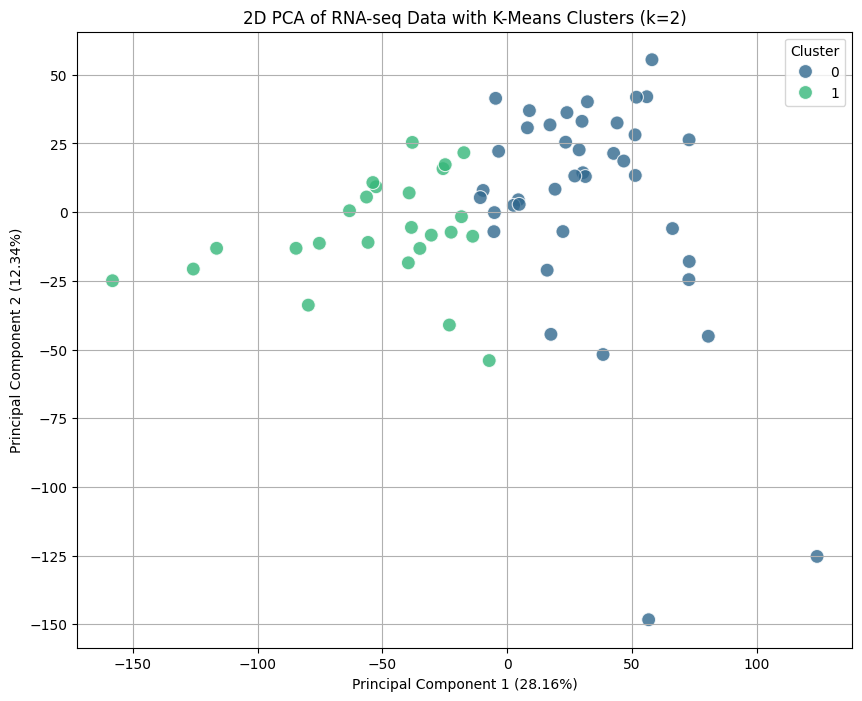

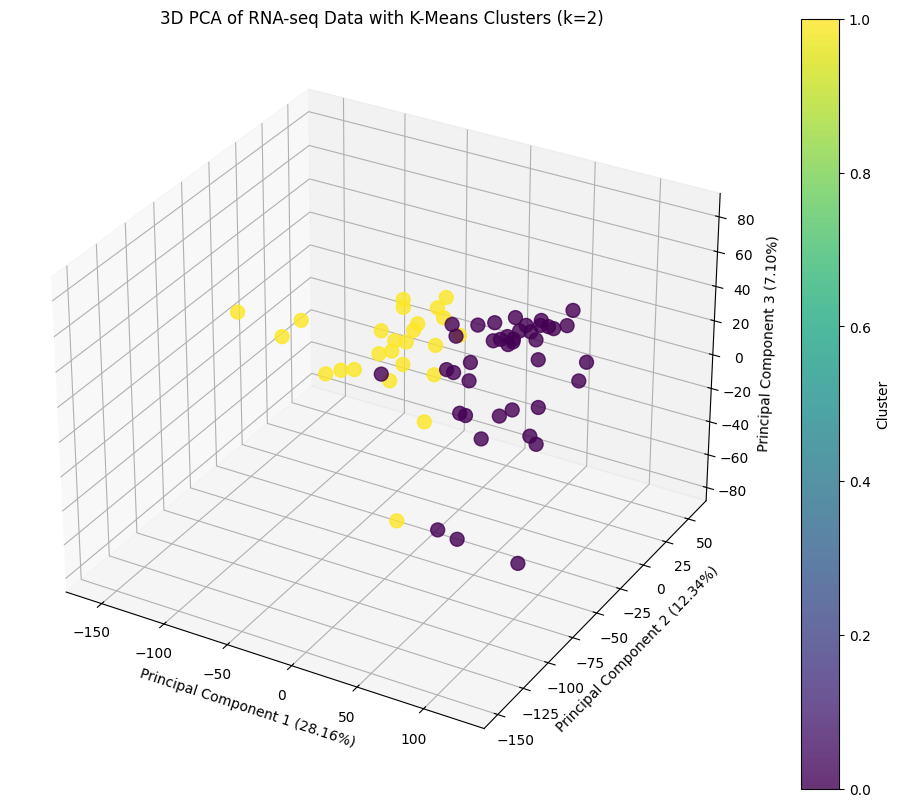


--- Unsupervised detection and visualization complete. ---


In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D # For 3D plot

print("\n--- Step 5: Unsupervised Detection (Clustering & Dimensionality Reduction) ---")

# 1. Feature Scaling
# It's crucial to scale your gene expression data before PCA and clustering
print("Scaling gene expression features (X)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X is from the previous step
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index) # Convert back to DataFrame for easier handling

print(f"Scaled features (X_scaled) shape: {X_scaled_df.shape}")
print("Scaled features head:")
print(X_scaled_df.head())

# 2. Dimensionality Reduction using PCA
# Let's reduce to 2 components for 2D visualization and 3 for 3D visualization
print("\nPerforming PCA for dimensionality reduction...")
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pca_2d_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'], index=X.index)

print(f"PCA (2 components) explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"Total explained variance (2 components): {pca_2d.explained_variance_ratio_.sum():.2f}")
print("PCA (2D) results head:")
print(pca_2d_df.head())

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
pca_3d_df = pd.DataFrame(data=X_pca_3d, columns=['PC1', 'PC2', 'PC3'], index=X.index)

print(f"\nPCA (3 components) explained variance ratio: {pca_3d.explained_variance_ratio_}")
print(f"Total explained variance (3 components): {pca_3d.explained_variance_ratio_.sum():.2f}")
print("PCA (3D) results head:")
print(pca_3d_df.head())


# 3. Clustering using K-Means (example with k=2 to look for 2 potential subgroups)
# You can experiment with different numbers of clusters (k)
print("\nPerforming K-Means clustering (k=2)...")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # n_init is important for robust results
clusters = kmeans.fit_predict(X_scaled) # Cluster on the scaled data

# Add cluster assignments to PCA results for plotting
pca_2d_df['Cluster'] = clusters
pca_3d_df['Cluster'] = clusters

print("Cluster assignments for first 5 samples:")
print(pca_2d_df['Cluster'].head())
print(f"Number of samples in Cluster 0: {sum(clusters == 0)}")
print(f"Number of samples in Cluster 1: {sum(clusters == 1)}")


# 4. Visualization of Clusters
print("\nGenerating PCA scatter plots with cluster assignments...")

# 2D Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_2d_df, palette='viridis', s=100, alpha=0.8)
plt.title('2D PCA of RNA-seq Data with K-Means Clusters (k=2)')
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()

# 3D Plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_3d_df['PC1'], pca_3d_df['PC2'], pca_3d_df['PC3'],
                     c=pca_3d_df['Cluster'], cmap='viridis', s=100, alpha=0.8)
ax.set_title('3D PCA of RNA-seq Data with K-Means Clusters (k=2)')
ax.set_xlabel(f'Principal Component 1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'Principal Component 2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_zlabel(f'Principal Component 3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

print("\n--- Unsupervised detection and visualization complete. ---")

In [35]:
import pandas as pd

print("\n--- Step 6: Characterizing Detected Clusters/Outliers ---")

# Assuming pca_2d_df (which now contains 'Cluster' assignments) is available from Step 5

# Get the samples in Cluster 1 (the smaller cluster/outlier)
outlier_samples_pca_df = pca_2d_df[pca_2d_df['Cluster'] == 1]

if not outlier_samples_pca_df.empty:
    print("\n--- Samples in Cluster 1 (Outlier/Small Group) ---")
    print(outlier_samples_pca_df)

    # Correctly get the TCGA Barcode from the index of pca_2d_df
    outlier_tcga_barcodes = outlier_samples_pca_df.index.tolist()
    print(f"\nTCGA Barcodes in Cluster 1: {outlier_tcga_barcodes}")

    if outlier_tcga_barcodes:
        # Retrieve full annotation information for these samples
        print("\n--- Full Annotation Details for Cluster 1 Samples (Corrected Retrieval) ---")
        # Filter annotations_df where 'id' (TCGA barcode) is in our list of outlier barcodes
        outlier_annotations = annotations_df[annotations_df['id'].isin(outlier_tcga_barcodes)]

        if not outlier_annotations.empty:
            print(outlier_annotations.to_string()) # .to_string() to display all rows/columns
        else:
            print(f"No matching annotation found in annotations_df for barcode(s): {outlier_tcga_barcodes}")
            print("This sample might not have a corresponding entry in your original annotations.csv.")

    else:
        print("No TCGA barcodes found in Cluster 1 (this should not happen if outlier_samples_pca_df is not empty).")

else:
    print("\nNo samples found in Cluster 1. This might happen if 'k' was set to 1, or if all samples clustered together.")

print("\n--- Characterization complete. ---")


--- Step 6: Characterizing Detected Clusters/Outliers ---

--- Samples in Cluster 1 (Outlier/Small Group) ---
                     PC1        PC2  Cluster
TCGA_Barcode                                
TCGA-KO-8415  -39.632963 -18.442201        1
TCGA-KO-8408  -30.440524  -8.360693        1
TCGA-KO-8414  -18.335296  -1.649562        1
TCGA-KN-8433  -79.734712 -33.837245        1
TCGA-KL-8335  -25.716666  15.834147        1
TCGA-KN-8426  -13.826234  -8.765623        1
TCGA-KO-8405  -23.181477 -41.075272        1
TCGA-KL-8346  -52.560034   9.244856        1
TCGA-KL-8331  -24.856355  17.291192        1
TCGA-KM-8477  -22.482802  -7.293500        1
TCGA-KN-8422  -75.306706 -11.323905        1
TCGA-KL-8337  -17.367997  21.651332        1
TCGA-KM-8439   -7.215921 -54.006825        1
TCGA-KO-8403  -38.398895  -5.550975        1
TCGA-KM-8476 -116.488738 -13.145407        1
TCGA-KL-8328  -53.849259  10.785643        1
TCGA-KM-8443  -38.040019  25.393454        1
TCGA-KL-8338  -39.309846   7.00591

In [36]:
import pandas as pd
import numpy as np

print("\n--- Step 7: Gene Signature Analysis of Outlier (TCGA-KO-8404) ---")

# Assuming X_scaled_df (scaled gene expression data with TCGA barcodes as index)
# and pca_2d_df (with 'Cluster' assignments) are available from previous steps.

# 1. Get the outlier sample's barcode
outlier_barcode = 'TCGA-KO-8404'
print(f"Analyzing outlier sample: {outlier_barcode}")

# 2. Separate scaled gene expression for the outlier vs. the main cluster
outlier_expression = X_scaled_df.loc[outlier_barcode] # This will be a Series
main_cluster_expression = X_scaled_df[pca_2d_df['Cluster'] == 0] # DataFrame of main cluster samples

print(f"\nShape of outlier expression: {outlier_expression.shape}")
print(f"Shape of main cluster expression: {main_cluster_expression.shape}")

# Calculate the mean expression for each gene in the main cluster
mean_main_cluster_expression = main_cluster_expression.mean(axis=0)

# 3. Calculate the difference in expression (Outlier vs. Main Cluster Mean)
# A higher positive difference means the gene is expressed higher in the outlier
# A lower negative difference means the gene is expressed lower in the outlier
expression_difference = outlier_expression - mean_main_cluster_expression

# Sort genes by their difference
top_upregulated_genes = expression_difference.sort_values(ascending=False).head(20)
top_downregulated_genes = expression_difference.sort_values(ascending=True).head(20)


print("\n--- Top 20 Genes Upregulated in TCGA-KO-8404 (Outlier) vs. Main Cluster ---")
print(top_upregulated_genes.to_string())

print("\n--- Top 20 Genes Downregulated in TCGA-KO-8404 (Outlier) vs. Main Cluster ---")
print(top_downregulated_genes.to_string())


# Optional: Also show absolute difference (genes that are just very different)
# print("\n--- Top 20 Genes with Largest Absolute Expression Difference ---")
# absolute_difference = expression_difference.abs().sort_values(ascending=False).head(20)
# print(absolute_difference.to_string())


print("\n--- Gene signature analysis complete. ---")


--- Step 7: Gene Signature Analysis of Outlier (TCGA-KO-8404) ---
Analyzing outlier sample: TCGA-KO-8404

Shape of outlier expression: (9673,)
Shape of main cluster expression: (40, 9673)

--- Top 20 Genes Upregulated in TCGA-KO-8404 (Outlier) vs. Main Cluster ---
ENSG00000266995.1     7.497479
ENSG00000202515.1     7.143053
ENSG00000268941.2     6.870560
ENSG00000172061.9     6.836572
ENSG00000103154.9     6.822327
ENSG00000184260.6     6.808893
ENSG00000143196.5     6.777003
ENSG00000199036.1     6.713201
ENSG00000166278.15    6.614137
ENSG00000060718.22    6.605317
ENSG00000149380.12    6.522462
ENSG00000196611.5     6.512015
ENSG00000279691.1     6.448037
ENSG00000278876.1     6.437688
ENSG00000272663.1     6.433195
ENSG00000128606.13    6.342678
ENSG00000072694.21    6.337249
ENSG00000143320.9     6.221864
ENSG00000268403.2     6.195361
ENSG00000159164.10    6.151775

--- Top 20 Genes Downregulated in TCGA-KO-8404 (Outlier) vs. Main Cluster ---
ENSG00000111319.13   -5.737696
ENSG